In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from iminuit import Minuit, cost
from scipy.stats import genextreme


my_colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')


save_figures = False
save_files = True

filelist=[
    "gev-mu=70,alpha=10,gamma=0,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.1,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.2,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.3,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.4,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.5,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.6,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.7,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.8,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=0.9,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.1,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.2,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.3,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.4,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.5,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.6,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.7,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.8,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=1.9,N=e6.csv",
    "gev-mu=70,alpha=10,gamma=2,N=e6.csv"
    ]
#filelist=["gev-mu=70,alpha=10,gamma=0.3,N=e6.csv"]

In [90]:
def x_in_bin_r(x,n_bins, shape_param, mu_param, alpha_param):#n_bins=N+1!
    cdf_val = genextreme.cdf(x, c=-shape_param, loc=mu_param, scale=alpha_param)
    for r in range(0,n_bins):
        if weibull_p_m(r,n_bins-1)<cdf_val<=weibull_p_m(r+1,n_bins-1):
            return r
        if weibull_p_m(n_bins,n_bins-1)<cdf_val:
            return n_bins-1
        if cdf_val<=weibull_p_m(1,n_bins-1):
            return 0
    return -1


def weibull_p_m(rank_m, N):
    """ 1 <= rank_m <= N
        N+1 = total number of bins"""
    p_m=rank_m / (N + 1)
    #print(f"P(m={rank_m},N={N}) = {p_m:.8f}")
    return p_m

In [92]:
directory = "data"
directory_figures="../Figures"
directory_results=directory+"/Results"

n_bins_array=[10,15,20,30,50,100]#,150,200]


"""Load Data from CSV file"""
for file in filelist:
    filepath = directory+ "/" + file
    print(f"Filepath: {filepath}")
    df   = pd.read_csv(filepath)
    data = np.array(df.values[:,0])

    if save_files:
        #raise NotImplementedError("Saving files is not implemented yet: format for direct use in latex")
        with open(f"{directory_results}/c_values.csv", "a") as f:
            #f.write("datafile;bins;VWLS;MLE;PWM;L-moments\n")
            f.write(f"{file};n_subset={len(data_subset)}\n")
            
    for n_bins in n_bins_array:
        print(f"n_bins: {n_bins}")
        """load true parameters from filename"""
        true_params = file.split("-")
        #print(true_params)
        true_params = true_params[1].split(",")
        print(true_params)
        for i in range(3):
            true_params[i] = float(true_params[i].split("=")[1])
        n_total_in_file=true_params[-1].split("=")[1].split(".")[0].replace("e","1e")
        #converting scientific notation e+3 to int
        n_total_in_file = int(float(n_total_in_file))
        true_params=true_params[:3]
        print(f"True parameters: {true_params}, n_total_in_file: {n_total_in_file}")


        """load parameters from results file"""
        filepath_parameters = directory_results+ "/calc_param_for_c.csv"
        read_this = False
        fit_parameters=[['exact',true_params,0]]
        with open(filepath_parameters, "r") as f:
            for line in f:
                #print(line)
                if file in line:
                    fit_stats = line.split(";")[1:]
                    bins_used = int(float(fit_stats[1].split("=")[1]))
                    if bins_used == n_bins:
                        read_this = True
                        print("found dataset")
                        continue
                if line=="\n" and read_this:
                    #print("end of parameters for this file")
                    break
                if read_this:
                    method,param1,param2,param3,n_used = line.split(",")
                    param1 = float(param1.split("=")[1])
                    param2 = float(param2.split("=")[1])
                    param3 = float(param3.split("=")[1])
                    n_used = int(n_used.split("=")[1])
                    fit_parameters.append([method,[param1, param2, param3],n_used])
        print(f"Parameters loaded from {filepath_parameters}:\n{fit_parameters}")



        """calculation parameters"""
        subset_n=10_000
        data_subset = data[n_bins:subset_n+n_bins]


        c_array=np.zeros(5)#ideal, vwls, mle, pwm, l_moments

        bin_list=np.empty((len(data_subset),5), dtype=int)
        count_array=np.empty((5,n_bins))
        bin_edges=np.linspace(0, n_bins, n_bins+1)

        for z in range(0,5):
            mu, alpha, gamma= fit_parameters[z][1]
            print(f"Calculating for {fit_parameters[z][0]} with parameters: mu={mu}, alpha={alpha}, gamma={gamma}")
            #take next random point and record bin [m-1,m], in which this point falls into
            for i in range(len(data_subset)):
                bin=x_in_bin_r(data_subset[i],n_bins,gamma, mu, alpha)
                if bin != -1:
                    bin_list[i, z] = bin
                else:
                    print(f"Data point {data_subset[i]} at position {i} does not fall into any bin.")

            count_array[z], _ = np.histogram(bin_list[:, z], bins=bin_edges)

            c_array[z]=np.sqrt(((count_array[z]/len(data_subset)-1/(n_bins))**2).sum())



        """storing the c values in a file for later comparison"""
        if save_files:
            #raise NotImplementedError("Saving files is not implemented yet: format for direct use in latex")
            with open(f"{directory_results}/c_values.csv", "a") as f:
                #f.write("datafile;bins;VWLS;MLE;PWM;L-moments\n")
                #f.write(f"{file};n_subset={len(data_subset)}\n")
                f.write(f"{n_bins} & {c_array[0]:.3f} & {c_array[1]:.3f} & {c_array[2]:.3f} & {c_array[3]:.3f} & {c_array[4]:.3f}\\\\ \n")
                print("saved")
        print("-"*50)

Filepath: data/gev-mu=70,alpha=10,gamma=0,N=e6.csv
n_bins: 10
['mu=70', 'alpha=10', 'gamma=0', 'N=e6.csv']
True parameters: [70.0, 10.0, 0.0], n_total_in_file: 1000000
found dataset
Parameters loaded from data/Results/calc_param_for_c.csv:
[['exact', [70.0, 10.0, 0.0], 0], ['VWLS', [70.11760626, 12.33868093, 0.00027377], 10], ['MLE', [71.13728211, 10.32327154, -0.10546465], 10], ['PWM', [82.31937288, 1.66199687, -3.65048995], 10], ['L-moments', [70.5363649, 11.43581417, -0.08651491], 10]]
Calculating for exact with parameters: mu=70.0, alpha=10.0, gamma=0.0
Calculating for VWLS with parameters: mu=70.11760626, alpha=12.33868093, gamma=0.00027377
Calculating for MLE with parameters: mu=71.13728211, alpha=10.32327154, gamma=-0.10546465
Calculating for PWM with parameters: mu=82.31937288, alpha=1.66199687, gamma=-3.65048995
Calculating for L-moments with parameters: mu=70.5363649, alpha=11.43581417, gamma=-0.08651491
saved
--------------------------------------------------
n_bins: 15
['mu

KeyboardInterrupt: 

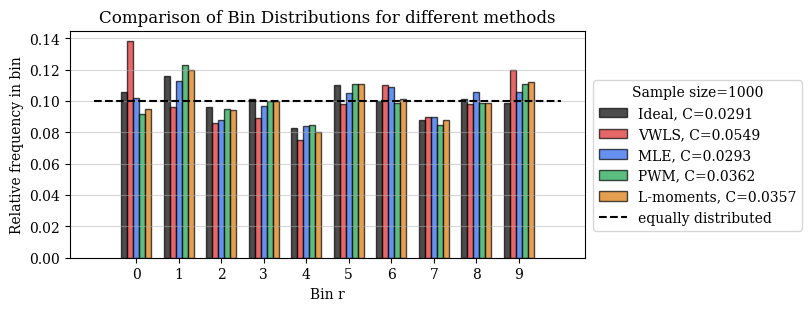

In [64]:
"""Histogram of the data points in each bin"""

fig,ax=plt.subplots(figsize=(8,3), layout='constrained')


label_list_plot=[
    f'Ideal, C={c_array[0]:.4f}',
    f'VWLS, C={c_array[1]:.4f}',
    f'MLE, C={c_array[2]:.4f}',
    f'PWM, C={c_array[3]:.4f}',
    f'L-moments, C={c_array[4]:.4f}'
    ]
colors_plot=[
    "black",
    my_colors['VWLS'],
    my_colors['MLE'],
    my_colors['PWM'],
    my_colors['L-moments']
    ]



ax.hist(bin_list, bins=n_bins, range=(0,n_bins), density=True, edgecolor='black', align='right', alpha=0.7, rwidth=0.7, color=colors_plot, label=label_list_plot)
ax.hlines(y=1/(n_bins), xmin=0, xmax=n_bins+1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Relative frequency in bin')
ax.set_title('Comparison of Bin Distributions for different methods')
ax.set_xticks(range(1,n_bins+1))
ax.set_xticklabels(range(0,n_bins))
fig.legend(title=f'Sample size={len(data_subset)}', loc="outside right")
ax.grid(axis='y', alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_{filename}.png")

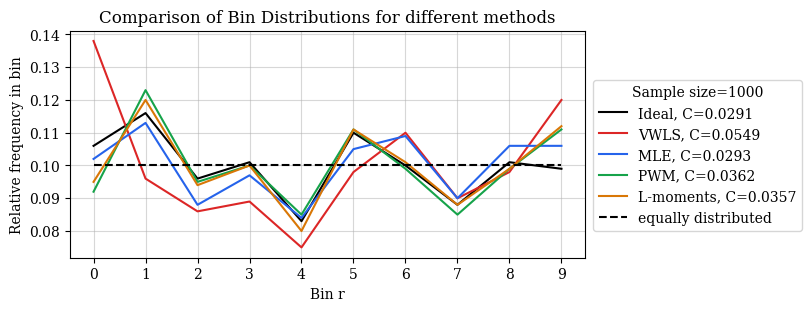

In [65]:
"""Histogram of the data points in each bin"""

fig,ax=plt.subplots(figsize=(8,3), layout='constrained')


label_list_plot=[
    f'Ideal, C={c_array[0]:.4f}',
    f'VWLS, C={c_array[1]:.4f}',
    f'MLE, C={c_array[2]:.4f}',
    f'PWM, C={c_array[3]:.4f}',
    f'L-moments, C={c_array[4]:.4f}'
    ]
colors_plot=[
    my_colors['VWLS'],
    my_colors['VWLS'],
    my_colors['MLE'],
    my_colors['PWM'],
    my_colors['L-moments']
    ]


ax.plot(rel_freq_array[0], label=label_list_plot[0], color='black')
ax.plot(rel_freq_array[1], label=label_list_plot[1], color=colors_plot[1])
ax.plot(rel_freq_array[2], label=label_list_plot[2], color=colors_plot[2])
ax.plot(rel_freq_array[3], label=label_list_plot[3], color=colors_plot[3])
ax.plot(rel_freq_array[4], label=label_list_plot[4], color=colors_plot[4])

ax.hlines(y=1/(n_bins), xmin=0, xmax=n_bins-1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Relative frequency in bin')
ax.set_title('Comparison of Bin Distributions for different methods')
ax.set_xticks(range(0,n_bins))
ax.set_xticklabels(range(0,n_bins))
fig.legend(title=f'Sample size={len(data_subset)}', loc="outside right")
ax.grid(alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_lines_{filename}.png")